In [1]:
import os
import sys
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from copy import deepcopy
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_add_pool
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

# -------------------------
# Repro / Device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

# -------------------------
# Ensure repo root is on sys.path for bcosgnn imports
# -------------------------
current_dir = Path.cwd()
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    return start # Fallback

project_root = find_repo_root(current_dir)
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cpu
Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [2]:
class ZincProcessedDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        data_path = Path(self.processed_dir) / "data.pt"
        try:
            self.data, self.slices = torch.load(data_path, weights_only=False)
        except TypeError: 
            self.data, self.slices = torch.load(data_path)

    @property
    def processed_file_names(self):
        return ['data.pt']

    def process(self):
        pass

# Locate Dataset
possible_paths = [
    "multi_class_Zinc/zinc_di_halo_benzene_data",
    "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
]
dataset_path = None
for rel_path in possible_paths:
    full_path = project_root / rel_path
    if full_path.exists():
        dataset_path = str(full_path.resolve())
        break
if dataset_path is None:
    dataset_path = str((project_root / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data").resolve())

print(f"Loading dataset from: {dataset_path}")
dataset = ZincProcessedDataset(root=dataset_path)

# Debug: Just print available keys to be sure, but DO NOT patch.
print("First graph keys:", dataset[0].keys)

Loading dataset from: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data
First graph keys: <bound method BaseData.keys of Data(x=[51, 10], edge_index=[2, 110], edge_attr=[110, 4], y=[1], explanation_mask=[51])>


In [3]:
class VanillaGINE4(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden_dim, num_classes, drop_ratio=0.5):
        super().__init__()
        self.node_proj = Linear(in_dim, hidden_dim)
        self.edge_proj = Linear(edge_dim, hidden_dim)

        def mlp():
            return Sequential(
                Linear(hidden_dim, 2 * hidden_dim),
                BatchNorm1d(2 * hidden_dim),
                ReLU(),
                Linear(2 * hidden_dim, hidden_dim),
            )

        self.conv1 = GINEConv(nn=mlp(), train_eps=True)
        self.bn1 = BatchNorm1d(hidden_dim)
        self.conv2 = GINEConv(nn=mlp(), train_eps=True)
        self.bn2 = BatchNorm1d(hidden_dim)
        self.conv3 = GINEConv(nn=mlp(), train_eps=True)
        self.bn3 = BatchNorm1d(hidden_dim)
        self.conv4 = GINEConv(nn=mlp(), train_eps=True)
        self.bn4 = BatchNorm1d(hidden_dim)

        self.drop_ratio = drop_ratio
        self.classifier = Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, edge_attr, batch=None):
        if batch is None: batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        
        h = self.node_proj(x.float())
        edge_emb = self.edge_proj(edge_attr.float())

        h = F.relu(self.bn1(self.conv1(h, edge_index, edge_attr=edge_emb)))
        h = F.relu(self.bn2(self.conv2(h, edge_index, edge_attr=edge_emb)))
        h = F.relu(self.bn3(self.conv3(h, edge_index, edge_attr=edge_emb)))
        h = F.relu(self.bn4(self.conv4(h, edge_index, edge_attr=edge_emb)))

        hg = global_add_pool(h, batch)
        hg = F.dropout(hg, p=self.drop_ratio, training=self.training)
        return self.classifier(hg)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(logits, batch.y.view(-1).long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_correct = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        pred = logits.argmax(dim=-1)
        total_correct += (pred == batch.y.view(-1).long()).sum().item()
    return total_correct / len(loader.dataset)



In [4]:


# Split Data
indices = np.arange(len(dataset))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n = len(indices)
train_dataset = dataset[indices[:int(0.8*n)]]
val_dataset = dataset[indices[int(0.8*n):int(0.9*n)]]
test_dataset = dataset[indices[int(0.9*n):]]

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Init Model
model = VanillaGINE4(
    in_dim=dataset.num_features, 
    edge_dim=dataset.num_edge_features, 
    hidden_dim=64, 
    num_classes=dataset.num_classes
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Train Loop
best_acc = 0.0
patience = 0
best_state = None

for epoch in range(1, 101):
    loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc = eval_one_epoch(model, val_loader, criterion)
    scheduler.step(loss)
    
    if val_acc > best_acc:
        best_acc = val_acc
        best_state = deepcopy(model.state_dict())
        patience = 0
    else:
        patience += 1
        
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {loss:.4f} | Val Acc {val_acc:.4f}")
        
    if patience >= 25:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state:
    model.load_state_dict(best_state)

test_acc = eval_one_epoch(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")



Epoch 10: Loss 0.0033 | Val Acc 1.0000
Epoch 20: Loss 0.0006 | Val Acc 1.0000
Early stopping at epoch 27.
Test Accuracy: 1.0000


In [13]:
import torch
import numpy as np
import random
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

def evaluate_ig_dynamic_k(loader, model, explainer, device='cpu', show_samples=5):
    model.eval()
    
    all_jaccards = []
    all_aurocs = []
    
    dataset = loader.dataset if hasattr(loader, 'dataset') else loader
    inspect_indices = set(random.sample(range(len(dataset)), show_samples))
    
    print(f"Evaluating IG (Dynamic K = GT Size) on {len(dataset)} graphs...")
    
    for i, data in enumerate(tqdm(dataset)):
        data = data.to(device)
        
        # 1. Get Ground Truth First (Needed for K)
        if hasattr(data, 'node_mask'):
            gt_mask = data.node_mask.cpu().numpy().astype(int)
        elif hasattr(data, 'explanation_mask'):
            gt_mask = data.explanation_mask.cpu().numpy().astype(int)
        else:
            continue
            
        # DYNAMIC K CALCULATION
        k_dynamic = int(gt_mask.sum())
        
        # If GT is empty (rare), skip or set K=1 to avoid errors
        if k_dynamic == 0: continue 

        # 2. Prediction
        logits = model(data.x, data.edge_index, data.edge_attr, batch=data.batch)
        pred_label = logits.argmax(dim=-1).item()
        
        # 3. Explanation
        explanation = explainer(
            x=data.x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
            batch=data.batch,
            target=pred_label
        )
        
        # 4. Process Scores
        node_attr = explanation.node_mask.abs().sum(dim=1)
        
        # 5. Top-K Binary Mask (Using Dynamic K)
        # Get indices of top K nodes where K is exactly the size of GT
        _, top_indices = torch.topk(node_attr, k_dynamic)
        
        pred_binary = torch.zeros(data.num_nodes, device=device)
        pred_binary[top_indices] = 1.0
        pred_binary_np = pred_binary.cpu().numpy()
        
        # Normalized scores for AUROC
        if node_attr.max() > node_attr.min():
            scores_norm = (node_attr - node_attr.min()) / (node_attr.max() - node_attr.min())
        else:
            scores_norm = torch.zeros_like(node_attr)
        scores_np = scores_norm.detach().cpu().numpy()
        
        # 6. Metrics
        # Node AUROC
        try:
            if len(np.unique(gt_mask)) > 1:
                all_aurocs.append(roc_auc_score(gt_mask, scores_np))
        except: pass

        # Jaccard
        intersect = (pred_binary_np * gt_mask).sum()
        union = (pred_binary_np + gt_mask).clip(0, 1).sum()
        jac = intersect / (union + 1e-8) if union > 0 else 0.0
        all_jaccards.append(jac)
        
        # 7. Inspection
        if i in inspect_indices:
            print(f"\n{'-'*20} Graph {i} Inspection {'-'*20}")
            print(f"GT Class: {data.y.item()} | Pred: {pred_label}")
            print(f"Dynamic K: {k_dynamic} (Size of GT)")
            print(f"Graph Jaccard: {jac:.4f}")

    return np.mean(all_jaccards), np.mean(all_aurocs)

# Run Evaluation
ig_jaccard, ig_auroc = evaluate_ig_dynamic_k(
    test_dataset, model, ig_explainer, device=DEVICE, show_samples=5
)

print("\n" + "="*40)
print(f"FINAL IG RESULTS (Dynamic K)")
print("="*40)
print(f"Avg Node Jaccard: {ig_jaccard:.4f}")
print(f"Avg Node AUROC:   {ig_auroc:.4f}")

Evaluating IG (Dynamic K = GT Size) on 900 graphs...


  0%|          | 0/900 [00:00<?, ?it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
  0%|          | 1/900 [00:00<02:44,  5.46it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
  0%|          | 3/900 [00:00<01:37,  9.24it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' 


-------------------- Graph 80 Inspection --------------------
GT Class: 7 | Pred: 7
Dynamic K: 9 (Size of GT)
Graph Jaccard: 0.8000


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
  9%|▉         | 85/900 [00:06<01:00, 13.57it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
 10%|▉         | 87/900 [00:06<01:01, 13.24it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explan


-------------------- Graph 300 Inspection --------------------
GT Class: 7 | Pred: 7
Dynamic K: 9 (Size of GT)
Graph Jaccard: 0.8000


...


-------------------- Graph 643 Inspection --------------------
GT Class: 7 | Pred: 7
Dynamic K: 9 (Size of GT)
Graph Jaccard: 0.8000


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
 72%|███████▏  | 647/900 [00:50<00:18, 13.78it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
 72%|███████▏  | 649/900 [00:50<00:18, 13.58it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the expl


-------------------- Graph 849 Inspection --------------------
GT Class: 6 | Pred: 6
Dynamic K: 9 (Size of GT)
Graph Jaccard: 0.2000


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
 95%|█████████▍| 853/900 [01:05<00:04,  9.85it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
 95%|█████████▌| 855/900 [01:06<00:04, 10.47it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/374555989.py:40: UserWarning: The 'target' should not be provided for the expl


FINAL IG RESULTS (Dynamic K)
Avg Node Jaccard: 0.5989
Avg Node AUROC:   0.8981


Visualizing 1 graph per class (Dynamic K)...


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3929/2859236624.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(


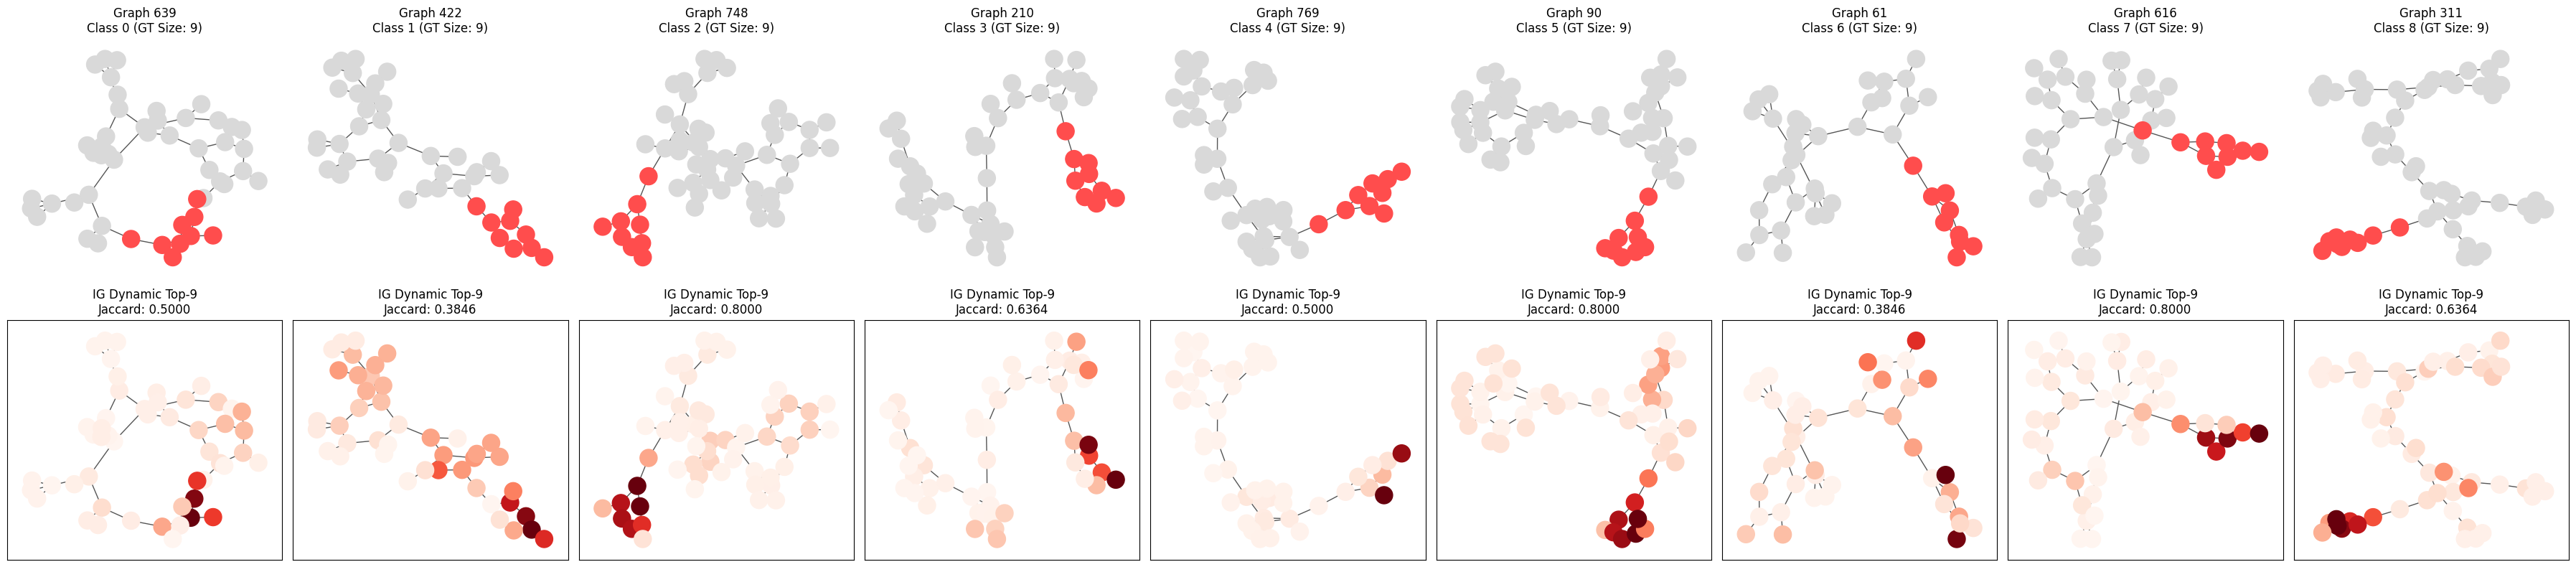

In [14]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import torch
import numpy as np
from torch_geometric.utils import to_networkx
from collections import defaultdict

def visualize_ig_dynamic_k(dataset, model, explainer, device='cpu'):
    model.eval()
    
    # Group by class
    class_indices = defaultdict(list)
    for idx, data in enumerate(dataset):
        y = data.y.item()
        class_indices[y].append(idx)
        
    selected_indices = []
    sorted_classes = sorted(class_indices.keys())
    for c in sorted_classes:
        indices = class_indices[c]
        if len(indices) > 0:
            selected_indices.append(random.choice(indices))
        
    num_plots = len(selected_indices)
    fig, axes = plt.subplots(2, num_plots, figsize=(4 * num_plots, 8))
    if num_plots == 1: axes = axes.reshape(2, 1)
    
    print(f"Visualizing 1 graph per class (Dynamic K)...")

    for i, idx in enumerate(selected_indices):
        data = dataset[idx].to(device)
        
        # Get GT First
        if hasattr(data, 'node_mask'):
            gt_mask = data.node_mask.cpu().numpy()
        elif hasattr(data, 'explanation_mask'):
            gt_mask = data.explanation_mask.cpu().numpy()
        else:
            gt_mask = np.zeros(data.num_nodes)
            
        k_dynamic = int(gt_mask.sum())
        if k_dynamic == 0: k_dynamic = 1 # Fallback for plotting if empty
        
        # Predict & Explain
        logits = model(data.x, data.edge_index, data.edge_attr, batch=data.batch)
        pred_label = logits.argmax(dim=-1).item()
        
        explanation = explainer(
            x=data.x, 
            edge_index=data.edge_index, 
            edge_attr=data.edge_attr, 
            batch=data.batch,
            target=pred_label
        )
        
        node_attr = explanation.node_mask.abs().sum(dim=1)
        
        # Norm Scores
        if node_attr.max() > node_attr.min():
            viz_scores = (node_attr - node_attr.min()) / (node_attr.max() - node_attr.min())
        else:
            viz_scores = torch.zeros_like(node_attr)
        viz_scores = viz_scores.detach().cpu().numpy()
        
        # Dynamic Top-K Selection
        _, top_indices = torch.topk(node_attr, k_dynamic)
        pred_binary = torch.zeros(data.num_nodes, device=device)
        pred_binary[top_indices] = 1.0
        pred_binary_np = pred_binary.cpu().numpy()
            
        # Jaccard
        intersect = (pred_binary_np * gt_mask).sum()
        union = (pred_binary_np + gt_mask).clip(0, 1).sum()
        jaccard = intersect / (union + 1e-8) if union > 0 else 0.0

        # Plot
        G = to_networkx(data, to_undirected=True)
        pos = nx.spring_layout(G, seed=42)
        
        # Row 1: GT
        ax_gt = axes[0, i] if num_plots > 1 else axes[0, 0]
        node_colors_gt = ['#ff4d4d' if m == 1 else '#d9d9d9' for m in gt_mask]
        nx.draw(G, pos, ax=ax_gt, node_color=node_colors_gt, node_size=300, edge_color='#555555', width=1.0, with_labels=False)
        ax_gt.set_title(f"Graph {idx}\nClass {data.y.item()} (GT Size: {k_dynamic})")
        
        # Row 2: Pred
        ax_pred = axes[1, i] if num_plots > 1 else axes[1, 0]
        im = nx.draw_networkx_nodes(G, pos, ax=ax_pred, node_color=viz_scores, cmap='Reds', node_size=300, vmin=0, vmax=1)
        nx.draw_networkx_edges(G, pos, ax=ax_pred, edge_color='#555555', width=1.0)
        ax_pred.set_title(f"IG Dynamic Top-{k_dynamic}\nJaccard: {jaccard:.4f}")
        
    plt.tight_layout()
    plt.show()

# Run
visualize_ig_dynamic_k(test_dataset, model, ig_explainer, device=DEVICE)

In [17]:
import numpy as np
import torch
import random
import warnings
from copy import deepcopy
from torch_geometric.loader import DataLoader
from torch_geometric.explain import Explainer, CaptumExplainer, ModelConfig
from sklearn.metrics import roc_auc_score
from tqdm import tqdm


SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 100
BATCH_SIZE = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Suppress repetitive warnings from Captum
warnings.filterwarnings("ignore", category=UserWarning)

final_results = {
    'acc': [],
    'dynamic_jaccard': [], 
    'auroc': []
}

print(f"Starting 5-Seed IG Experiment (Dynamic K) on {DEVICE}...")
print("=" * 60)

# --- FIX 1: Define dataset_list explicitly ---
# The previous error happened because 'dataset' exists, but 'dataset_list' didn't.
if 'dataset' in locals():
    dataset_list = list(dataset)
else:
    raise NameError("Variable 'dataset' not found. Please ensure your dataset is loaded in previous cells.")

for run_id, seed in enumerate(SEEDS):
    print(f"RUN {run_id+1}/{len(SEEDS)} | SEED: {seed}")
    
    # 1. Seeding
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    # 2. Data Split
    indices = np.arange(len(dataset_list))
    np.random.shuffle(indices)
    
    n_total = len(indices)
    n_train = int(0.8 * n_total)
    n_val = int(0.1 * n_total)
    
    train_idx = indices[:n_train]
    val_idx = indices[n_train : n_train + n_val]
    test_idx = indices[n_train + n_val :]
    
    train_set = [dataset_list[i] for i in train_idx]
    val_set = [dataset_list[i] for i in val_idx]
    test_set = [dataset_list[i] for i in test_idx]
    
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
    
    # 3. Model Setup (VanillaGINE4)
    model = VanillaGINE4(
        in_dim=dataset.num_features, 
        edge_dim=dataset.num_edge_features, 
        hidden_dim=64, 
        num_classes=dataset.num_classes
    ).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()
    
    # 4. Training Loop
    best_val_acc = 0.0
    best_state = None
    
    for epoch in range(EPOCHS):
        # Using the helper functions defined in your notebook
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc = eval_one_epoch(model, val_loader, criterion)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            
    # Load best model for evaluation
    if best_state is not None:
        model.load_state_dict(best_state)
        
    # 5. Test Accuracy
    test_acc = eval_one_epoch(model, test_loader, criterion)
    final_results['acc'].append(test_acc)
    print(f"  Best Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # 6. Explainer Setup
    ig_explainer = Explainer(
        model=model,
        algorithm=CaptumExplainer('IntegratedGradients'),
        explanation_type='model',
        model_config=ModelConfig(
            mode='multiclass_classification',
            task_level='graph',
            return_type='probs',
        ),
        node_mask_type='attributes',
        edge_mask_type=None,
    )
    
    # 7. Explanation Loop
    model.eval()
    seed_jaccards = []
    seed_aurocs = []
    
    for data in tqdm(test_set, desc="  Explaining", leave=False):
        data = data.to(DEVICE)
        
        # Check Ground Truth
        if hasattr(data, 'node_mask'):
            gt_mask = data.node_mask.cpu().numpy().astype(int)
        elif hasattr(data, 'explanation_mask'):
            gt_mask = data.explanation_mask.cpu().numpy().astype(int)
        else:
            continue
            
        # Calculate Dynamic K (Size of Motif)
        k_dynamic = int(gt_mask.sum())
        if k_dynamic == 0: continue
        
        # --- FIX 2: Pass edge_attr to model ---
        logits = model(data.x, data.edge_index, data.edge_attr, batch=data.batch)
        pred_label = logits.argmax(dim=-1).item()
        
        # --- FIX 3: Pass edge_attr to explainer ---
        explanation = ig_explainer(
            x=data.x, 
            edge_index=data.edge_index, 
            edge_attr=data.edge_attr, 
            batch=data.batch, 
            target=pred_label
        )
        
        # Process Attribution
        node_attr = explanation.node_mask.abs().sum(dim=1)
        
        # Dynamic Top-K Selection
        _, top_indices = torch.topk(node_attr, k_dynamic)
        pred_binary = torch.zeros(data.num_nodes, device=DEVICE)
        pred_binary[top_indices] = 1.0
        pred_binary_np = pred_binary.cpu().numpy()
        
        # AUROC Scores (Normalized)
        if node_attr.max() > node_attr.min():
            scores_norm = (node_attr - node_attr.min()) / (node_attr.max() - node_attr.min())
        else:
            scores_norm = torch.zeros_like(node_attr)
        scores_np = scores_norm.detach().cpu().numpy()
        
        # Metrics
        try:
            if len(np.unique(gt_mask)) > 1:
                auc = roc_auc_score(gt_mask, scores_np)
                seed_aurocs.append(auc)
        except: pass
        
        intersect = (pred_binary_np * gt_mask).sum()
        union = (pred_binary_np + gt_mask).clip(0, 1).sum()
        jac = intersect / (union + 1e-8) if union > 0 else 0.0
        seed_jaccards.append(jac)
        
    mean_jac = np.mean(seed_jaccards)
    mean_auc = np.mean(seed_aurocs)
    
    final_results['dynamic_jaccard'].append(mean_jac)
    final_results['auroc'].append(mean_auc)
    print(f"  Metrics -> Dynamic Jaccard: {mean_jac:.4f} | AUROC: {mean_auc:.4f}")

# -------------------------------------------------
# Final Reporting
# -------------------------------------------------
print("\n" + "="*60)
print(f"FINAL RESULTS (5 SEEDS) | Metric: Dynamic K (GT Size)")
print("="*60)
print(f"Test Accuracy: {np.mean(final_results['acc']):.4f} ± {np.std(final_results['acc']):.4f}")
print(f"Node Jaccard:  {np.mean(final_results['dynamic_jaccard']):.4f} ± {np.std(final_results['dynamic_jaccard']):.4f}")
print(f"Node AUROC:    {np.mean(final_results['auroc']):.4f} ± {np.std(final_results['auroc']):.4f}")

Starting 5-Seed IG Experiment (Dynamic K) on cpu...
RUN 1/5 | SEED: 0


KeyboardInterrupt: 